**SECTION 1 — IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


**SECTION 2 — Dataseet** *italicized text*

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path_aapl = "/content/drive/MyDrive/CSV File/AI and Finance dataset/aapl_us_2025.csv"
path_msft = "/content/drive/MyDrive/CSV File/AI and Finance dataset/MSFT_yfinance.csv"

aapl = pd.read_csv(path_aapl)


msft = pd.read_csv(path_msft)

msft.columns = msft.columns.str.strip()

if '' in msft.columns:
    msft = msft.drop(columns=[''])

In [4]:
# Load CSV files
aapl = pd.read_csv(path_aapl)
msft = pd.read_csv(path_msft)

# Clean columns
msft.columns = msft.columns.str.strip()

# Convert Date
aapl["Date"] = pd.to_datetime(aapl["Date"])
msft["Date"] = pd.to_datetime(msft["Date"])

# Keep required columns
aapl = aapl[["Date", "Close"]].rename(columns={"Close":"Close_AAPL"})
msft = msft[["Date", "Close"]].rename(columns={"Close":"Close_MSFT"})

# Merge
data = pd.merge(aapl, msft, on="Date", how="inner")
data = data.sort_values("Date").reset_index(drop=True)

# Compute returns
data["R_AAPL"] = data["Close_AAPL"].pct_change()
data["R_MSFT"] = data["Close_MSFT"].pct_change()

data = data.dropna().reset_index(drop=True)

data.head()

,Date,Close_AAPL,Close_MSFT,R_AAPL,R_MSFT
0,2010-01-05,6.46558,23.137524,0.001715,0.000323
1,2010-01-06,6.36237,22.995537,-0.015963,-0.006137
2,2010-01-07,6.35113,22.756380,-0.001767,-0.010400
3,2010-01-08,6.39387,22.913322,0.006730,0.006897
4,2010-01-11,6.33709,22.621864,-0.008880,-0.012720


**SECTION 3 — TRAIN / TEST SPLIT**

In [5]:
data["Year"] = data["Date"].dt.year

train = data[data["Year"] < 2024].copy()
test  = data[data["Year"] >= 2024].copy()

print("Train size:", train.shape)
print("Test size:", test.shape)


Train size: (3521, 6)
Test size: (263, 6)


**SECTION 4 — MARKOWITZ OPTIMIZATION (TRAINING SET)**

In [6]:
mu_train = train[["R_AAPL","R_MSFT"]].mean().values
cov_train = train[["R_AAPL","R_MSFT"]].cov().values

inv_cov = np.linalg.inv(cov_train)
ones = np.ones(len(mu_train))

# Minimum Variance Portfolio
w_min = inv_cov @ ones / (ones.T @ inv_cov @ ones)

# Tangency Portfolio (rf = 0)
w_tan = inv_cov @ mu_train / (ones.T @ inv_cov @ mu_train)

print("Minimum Variance Weights:", np.round(w_min,4))
print("Tangency Portfolio Weights:", np.round(w_tan,4))


Minimum Variance Weights: [0.398 0.602]
Tangency Portfolio Weights: [0.5909 0.4091]


**SECTION 4B — DYNAMIC COVARIANCE Σt (EWMA, TRAINED ON 2010–2023)**

In [7]:


from scipy.stats import multivariate_normal

returns_full = data[["R_AAPL", "R_MSFT"]].values

def run_ewma(returns, lam, seed_cov):
    n = len(returns)
    sigmas = np.zeros((n, 2, 2))
    sigmas[0] = seed_cov
    for t in range(1, n):
        r_prev = returns[t-1].reshape(-1, 1)
        sigmas[t] = lam * sigmas[t-1] + (1 - lam) * (r_prev @ r_prev.T)
    return sigmas

def train_loglik(lam, returns_train, warmup=30):
    seed_cov = np.cov(returns_train[:warmup].T)
    sigmas = run_ewma(returns_train, lam, seed_cov)
    ll = 0.0
    for t in range(warmup, len(returns_train)):
        try:
            ll += multivariate_normal.logpdf(returns_train[t], mean=[0, 0], cov=sigmas[t])
        except np.linalg.LinAlgError:
            continue
    return ll

# Fit lambda on the TRAINING set only
lambda_grid = [0.90, 0.92, 0.94, 0.96, 0.98]
train_returns_arr = train[["R_AAPL", "R_MSFT"]].values
lik_scores = [train_loglik(lam, train_returns_arr) for lam in lambda_grid]
lambda_star = lambda_grid[int(np.argmax(lik_scores))]

print("EWMA lambda candidates :", lambda_grid)
print("Log-likelihood scores  :", [round(s, 2) for s in lik_scores])
print("Selected lambda*        :", lambda_star)

# Apply the FITTED lambda dynamically across the FULL sample (train + test)
# -> one Sigma_t per trading day, seeded from the first month of training data.
seed_cov_full = np.cov(returns_full[:30].T)
sigmas_full = run_ewma(returns_full, lambda_star, seed_cov_full)

data["Sigma_AA"] = sigmas_full[:, 0, 0]
data["Sigma_MM"] = sigmas_full[:, 1, 1]
data["Sigma_AM"] = sigmas_full[:, 0, 1]

data[["Date", "Sigma_AA", "Sigma_MM", "Sigma_AM"]].tail()


EWMA lambda candidates : [0.9, 0.92, 0.94, 0.96, 0.98]
Log-likelihood scores  : [np.float64(19203.67), np.float64(19317.4), np.float64(19428.37), np.float64(19533.91), np.float64(19596.67)]
Selected lambda*        : 0.98


,Date,Sigma_AA,Sigma_MM,Sigma_AM
3779,2025-01-13,0.000156,0.000159,0.000089
3780,2025-01-14,0.000155,0.000156,0.000088
3781,2025-01-15,0.000152,0.000153,0.000087
3782,2025-01-16,0.000157,0.000163,0.000095
3783,2025-01-17,0.000187,0.000160,0.000096


**SECTION 4C — DAILY MINIMUM VARIANCE WEIGHTS FROM Σt**

In [24]:


def min_var_weights_from_row(row):
    Sigma_t = np.array([[row["Sigma_AA"], row["Sigma_AM"]],
                         [row["Sigma_AM"], row["Sigma_MM"]]])
    try:
        inv_cov = np.linalg.inv(Sigma_t)
    except np.linalg.LinAlgError:
        return pd.Series([0.5, 0.5])
    ones = np.ones(2)
    w = inv_cov @ ones / (ones.T @ inv_cov @ ones)

    w = np.clip(w, 0, 1)
    w = w / w.sum()
    return pd.Series(w)

data[["w_AAPL_dyn", "w_MSFT_dyn"]] = data.apply(min_var_weights_from_row, axis=1)

data[["Date", "w_AAPL_dyn", "w_MSFT_dyn"]].tail()


,Date,w_AAPL_dyn,w_MSFT_dyn
3779,2025-01-13,0.509958,0.490042
3780,2025-01-14,0.503270,0.496730
3781,2025-01-15,0.502546,0.497454
3782,2025-01-16,0.523135,0.476865
3783,2025-01-17,0.414200,0.585800


**SECTION 5 — MARKOWITZ BULLET (TRAIN + TEST)**

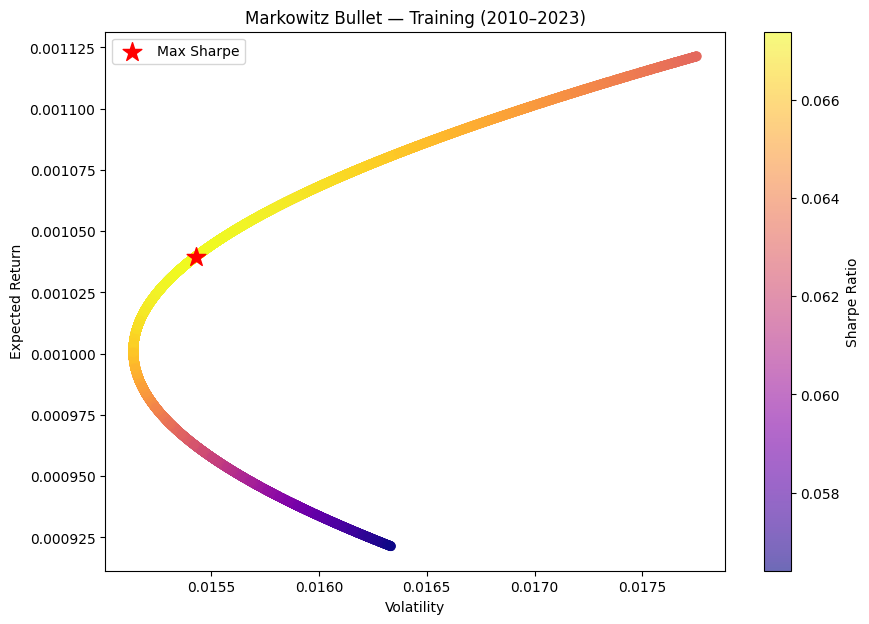

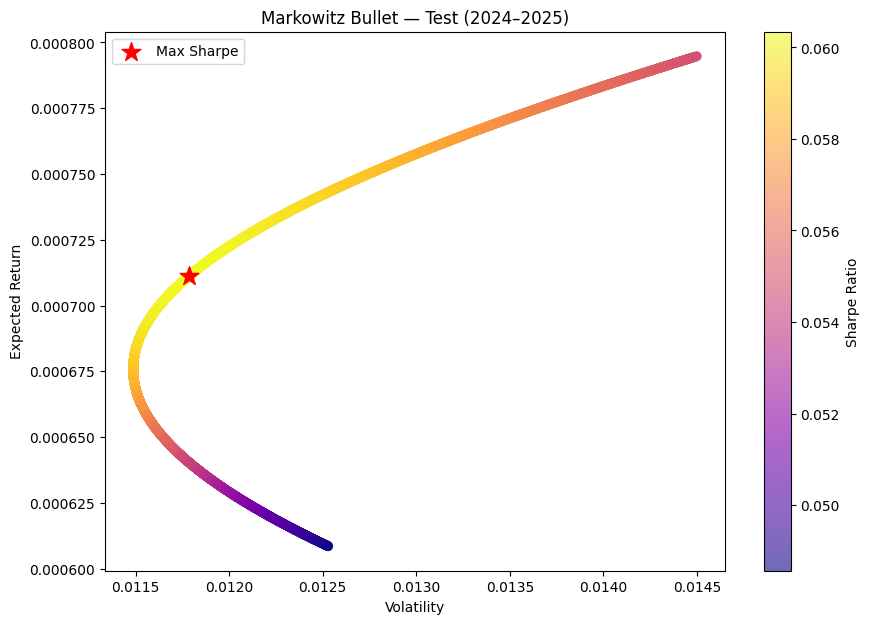

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def monte_carlo_bullet(mu, cov, title, n_portfolios=15000):

    results = np.zeros((3, n_portfolios))

    for i in range(n_portfolios):
        # Generate random weights
        weights = np.random.random(2)
        weights /= np.sum(weights)

        # Portfolio return
        port_return = np.dot(weights, mu)

        # Portfolio volatility
        port_vol = np.sqrt(weights.T @ cov @ weights)

        # Sharpe ratio (assuming rf = 0)
        sharpe = port_return / port_vol

        results[0,i] = port_vol
        results[1,i] = port_return
        results[2,i] = sharpe

    # Plot
    plt.figure(figsize=(10,7))
    scatter = plt.scatter(results[0,:], results[1,:],
                          c=results[2,:],
                          cmap='plasma',
                          alpha=0.6)

    # Highlight Maximum Sharpe
    max_idx = np.argmax(results[2])
    plt.scatter(results[0,max_idx],
                results[1,max_idx],
                color='red',
                marker='*',
                s=200,
                label='Max Sharpe')

    plt.xlabel("Volatility")
    plt.ylabel("Expected Return")
    plt.title(title)
    plt.colorbar(scatter, label="Sharpe Ratio")
    plt.legend()
    plt.show()


# ============================
# TRAINING BULLET
# ============================

monte_carlo_bullet(
    mu_train,
    cov_train,
    "Markowitz Bullet — Training (2010–2023)"
)

# ============================
# TEST BULLET
# ============================

mu_test = test[["R_AAPL","R_MSFT"]].mean().values
cov_test = test[["R_AAPL","R_MSFT"]].cov().values

monte_carlo_bullet(
    mu_test,
    cov_test,
    "Markowitz Bullet — Test (2024–2025)"
)


**SECTION 6 — DYNAMIC PORTFOLIO SIMULATION (TEST SET)**

In [10]:
initial_capital = 100000

portfolio_value = initial_capital
holding_AAPL = w_min[0] * portfolio_value
holding_MSFT = w_min[1] * portfolio_value

V_p, V_1, V_2 = [], [], []
trade_AAPL, trade_MSFT = [], []

for i in range(len(test)):

    r1 = test.iloc[i]["R_AAPL"]
    r2 = test.iloc[i]["R_MSFT"]

    holding_AAPL *= (1 + r1)
    holding_MSFT *= (1 + r2)

    portfolio_value = holding_AAPL + holding_MSFT

    target_AAPL = w_min[0] * portfolio_value
    target_MSFT = w_min[1] * portfolio_value

    trade_AAPL.append(target_AAPL - holding_AAPL)
    trade_MSFT.append(target_MSFT - holding_MSFT)

    holding_AAPL = target_AAPL
    holding_MSFT = target_MSFT

    V_p.append(portfolio_value)
    V_1.append(holding_AAPL)
    V_2.append(holding_MSFT)

test = test.reset_index(drop=True)
test["V_P"] = V_p
test["V_AAPL"] = V_1
test["V_MSFT"] = V_2
test["Trade_AAPL"] = trade_AAPL
test["Trade_MSFT"] = trade_MSFT

test.head()


,Date,Close_AAPL,Close_MSFT,R_AAPL,R_MSFT,Year,V_P,V_AAPL,V_MSFT,Trade_AAPL,Trade_MSFT
0,2024-01-02,184.938,365.421570,-0.035792,-0.013749,2024,97747.856495,38901.504553,58846.351942,528.136708,-528.136708
1,2024-01-03,183.554,365.155579,-0.007484,-0.000728,2024,97413.899223,38768.596878,58645.302345,158.215200,-158.215200
2,2024-01-04,181.222,362.534668,-0.012705,-0.007178,2024,96500.427816,38405.055279,58095.372538,129.002109,-129.002109
3,2024-01-05,180.495,362.347473,-0.004012,-0.000516,2024,96316.362461,38331.801301,57984.561160,80.813825,-80.813825
4,2024-01-08,184.859,369.185486,0.024178,0.018871,2024,98337.398253,39136.129252,59201.269001,-122.456619,122.456619


**EXPLICIT DAILY CAPITAL ALLOCATION TABLE (TEST SET)**

In [11]:


capital_table = test[[
    "Date",
    "V_P",
    "V_AAPL",
    "V_MSFT"
]].copy()

print("Daily Capital Allocation (Test Set 2024–2025)")
display(capital_table.head())


Daily Capital Allocation (Test Set 2024–2025)


,Date,V_P,V_AAPL,V_MSFT
0,2024-01-02,97747.856495,38901.504553,58846.351942
1,2024-01-03,97413.899223,38768.596878,58645.302345
2,2024-01-04,96500.427816,38405.055279,58095.372538
3,2024-01-05,96316.362461,38331.801301,57984.561160
4,2024-01-08,98337.398253,39136.129252,59201.269001


**DAILY TRADE QUANTITIES (BUY / SELL)**

In [12]:


trade_table = test[[
    "Date",
    "Trade_AAPL",
    "Trade_MSFT"
]].copy()

print("Daily Trade Quantities (Positive = Buy, Negative = Sell)")
display(trade_table.head())


Daily Trade Quantities (Positive = Buy, Negative = Sell)


,Date,Trade_AAPL,Trade_MSFT
0,2024-01-02,528.136708,-528.136708
1,2024-01-03,158.215200,-158.215200
2,2024-01-04,129.002109,-129.002109
3,2024-01-05,80.813825,-80.813825
4,2024-01-08,-122.456619,122.456619


**SECTION 6B — DYNAMIC PORTFOLIO SIMULATION (Σt-BASED WEIGHTS)**

In [26]:


test_dyn = data[data["Year"] >= 2024][[
    "Date", "R_AAPL", "R_MSFT", "Sigma_AA", "Sigma_MM", "Sigma_AM",
    "w_AAPL_dyn", "w_MSFT_dyn"
]].copy().reset_index(drop=True)

initial_capital = 100000
portfolio_value = initial_capital
holding_AAPL = test_dyn.loc[0, "w_AAPL_dyn"] * portfolio_value
holding_MSFT = test_dyn.loc[0, "w_MSFT_dyn"] * portfolio_value

V_p, V_1, V_2 = [], [], []
trade_AAPL, trade_MSFT = [], []
w1_used, w2_used = [], []

for i in range(len(test_dyn)):
    r1 = test_dyn.iloc[i]["R_AAPL"]
    r2 = test_dyn.iloc[i]["R_MSFT"]

    holding_AAPL *= (1 + r1)
    holding_MSFT *= (1 + r2)
    portfolio_value = holding_AAPL + holding_MSFT

    w1_t = test_dyn.iloc[i]["w_AAPL_dyn"]   # today's Sigma_t-based target weight
    w2_t = test_dyn.iloc[i]["w_MSFT_dyn"]

    target_AAPL = w1_t * portfolio_value
    target_MSFT = w2_t * portfolio_value

    trade_AAPL.append(target_AAPL - holding_AAPL)
    trade_MSFT.append(target_MSFT - holding_MSFT)

    holding_AAPL = target_AAPL
    holding_MSFT = target_MSFT

    V_p.append(portfolio_value)
    V_1.append(holding_AAPL)
    V_2.append(holding_MSFT)
    w1_used.append(w1_t)
    w2_used.append(w2_t)

test_dyn["V_P"] = V_p
test_dyn["V_AAPL"] = V_1
test_dyn["V_MSFT"] = V_2
test_dyn["Trade_AAPL"] = trade_AAPL
test_dyn["Trade_MSFT"] = trade_MSFT

# Portfolio return using that SAME day's dynamic weight (mirrors Section 7's
# logic, but with w_t instead of the fixed w_min)
test_dyn["Portfolio_Return"] = (
    pd.Series(w1_used) * test_dyn["R_AAPL"] +
    pd.Series(w2_used) * test_dyn["R_MSFT"]
)

test_dyn.head()


,Date,R_AAPL,R_MSFT,Sigma_AA,Sigma_MM,Sigma_AM,w_AAPL_dyn,w_MSFT_dyn,V_P,V_AAPL,V_MSFT,Trade_AAPL,Trade_MSFT,Portfolio_Return
0,2024-01-02,-0.035792,-0.013749,0.000118,0.000161,0.000076,0.670581,0.329419,97146.951075,65144.943924,32002.007151,486.938909,-486.938909,-0.028530
1,2024-01-03,-0.007484,-0.000728,0.000141,0.000161,0.000084,0.576597,0.423403,96636.138748,55720.114951,40916.023797,-8937.310981,8937.310981,-0.004623
2,2024-01-04,-0.012705,-0.007178,0.000139,0.000158,0.000083,0.571867,0.428133,95634.555462,54690.268531,40944.286931,-321.938621,321.938621,-0.010338
3,2024-01-05,-0.004012,-0.000516,0.000140,0.000156,0.000083,0.563079,0.436921,95394.015428,53714.336781,41679.678647,-756.533304,756.533304,-0.002484
4,2024-01-08,0.024178,0.018871,0.000137,0.000153,0.000081,0.561718,0.438282,97479.273125,54755.902940,42723.370185,-257.136662,257.136662,0.021852


**SECTION 7 — PORTFOLIO RETURNS**

In [14]:
test["Portfolio_Return"] = (
    w_min[0] * test["R_AAPL"] +
    w_min[1] * test["R_MSFT"]
)


**SECTION 8 — ROLLING VaR (DYNAMIC, 250-DAY WINDOW)**

In [15]:
window = 250

rolling_VaR = test["Portfolio_Return"].rolling(window).quantile(0.05)
test["Rolling_VaR"] = rolling_VaR


**SECTION 8B — NORMAL-DISTRIBUTION VaR & ES (DYNAMIC, DAY BY DAY)**

In [29]:
# Requirement 3(i): "Assume normally distributed returns and compute,
# dynamically and day by day, VaR_t and ES_t at 95% confidence level."
# `norm` was imported in Section 1 but never used until now.

alpha = 0.05
z_alpha = norm.ppf(alpha)                   # approx -1.645
es_multiplier = norm.pdf(z_alpha) / alpha   # approx 2.063

# Means are far less forecastable day-to-day than variances, so (as is
# standard practice, e.g. in GARCH-type models) we hold the mean fixed at
# its trained value and only let the covariance/weights move dynamically.
mu_p = w_min @ mu_train

sigma_p2 = (
    test_dyn["w_AAPL_dyn"]**2 * test_dyn["Sigma_AA"] +
    test_dyn["w_MSFT_dyn"]**2 * test_dyn["Sigma_MM"] +
    2 * test_dyn["w_AAPL_dyn"] * test_dyn["w_MSFT_dyn"] * test_dyn["Sigma_AM"]
)
test_dyn["Sigma_p"] = np.sqrt(sigma_p2)

test_dyn["VaR_normal"] = mu_p + test_dyn["Sigma_p"] * z_alpha
test_dyn["ES_normal"] = mu_p - test_dyn["Sigma_p"] * es_multiplier

test_dyn[["Date", "Sigma_p", "VaR_normal", "ES_normal"]].tail()


,Date,Sigma_p,VaR_normal,ES_normal
258,2025-01-13,0.011101,-0.017258,-0.021897
259,2025-01-14,0.011038,-0.017155,-0.021767
260,2025-01-15,0.010943,-0.016999,-0.021572
261,2025-01-16,0.011293,-0.017575,-0.022294
262,2025-01-17,0.011567,-0.018026,-0.022859


**SECTION 8C — STRESS SCENARIO GENERATION (VOLATILITY-REGIME ADAPTIVE)**

In [30]:
# Requirement 3(ii)-(iii): "a dynamic scenario generation model that
# adapts to recent market conditions (e.g., volatility spikes, regime
# shifts)" and recomputing VaR_t / ES_t from SIMULATED stress scenarios.
#
# Approach:
#  1. Detect the volatility regime each day: short-term realized vol (20d)
#     vs long-term realized vol (120d) of the portfolio.
#  2. When short-term vol spikes above long-term vol, scale Sigma_t up by
#     that spike ratio squared (variance scales with vol^2) -> Sigma_stress.
#  3. Monte Carlo simulate N portfolio return draws under Sigma_stress and
#     take the empirical 5% quantile / tail mean as VaR_stress / ES_stress.

short_win, long_win = 20, 120

# Reference return series (static weights) used only to DETECT the regime
port_ret_ref = w_min[0] * data["R_AAPL"] + w_min[1] * data["R_MSFT"]
vol_short = port_ret_ref.rolling(short_win).std()
vol_long = port_ret_ref.rolling(long_win).std()
vol_ratio = (vol_short / vol_long).clip(lower=1.0)   # only scale UP, never down

data["Vol_Ratio"] = vol_ratio
data["Stress_Multiplier"] = (vol_ratio**2).fillna(1.0)

n_sims = 5000
np.random.seed(42)

test_idx = data[data["Year"] >= 2024].index
VaR_stress, ES_stress, stress_mult_used = [], [], []

for idx in test_idx:
    Sigma_t = np.array([
        [data.loc[idx, "Sigma_AA"], data.loc[idx, "Sigma_AM"]],
        [data.loc[idx, "Sigma_AM"], data.loc[idx, "Sigma_MM"]]
    ])
    stress_mult = data.loc[idx, "Stress_Multiplier"]
    Sigma_stress = Sigma_t * stress_mult

    w_t = data.loc[idx, ["w_AAPL_dyn", "w_MSFT_dyn"]].values.astype(float)

    sims = np.random.multivariate_normal([0, 0], Sigma_stress, size=n_sims)
    port_sims = sims @ w_t + mu_p

    q = np.quantile(port_sims, alpha)
    VaR_stress.append(q)
    ES_stress.append(port_sims[port_sims <= q].mean())
    stress_mult_used.append(stress_mult)

test_dyn["VaR_stress"] = VaR_stress
test_dyn["ES_stress"] = ES_stress
test_dyn["Stress_Multiplier"] = stress_mult_used

test_dyn[["Date", "VaR_normal", "VaR_stress", "ES_normal", "ES_stress", "Stress_Multiplier"]].tail(10)


,Date,VaR_normal,VaR_stress,ES_normal,ES_stress,Stress_Multiplier
253,2025-01-03,-0.017252,-0.016478,-0.021889,-0.020987,1.000000
254,2025-01-06,-0.017097,-0.016572,-0.021694,-0.020687,1.000000
255,2025-01-07,-0.017025,-0.017503,-0.021604,-0.022132,1.000000
256,2025-01-08,-0.017062,-0.017524,-0.021651,-0.022037,1.000000
257,2025-01-10,-0.016899,-0.017045,-0.021447,-0.021626,1.001274
258,2025-01-13,-0.017258,-0.017185,-0.021897,-0.021633,1.000000
259,2025-01-14,-0.017155,-0.016665,-0.021767,-0.021307,1.000000
260,2025-01-15,-0.016999,-0.019421,-0.021572,-0.024373,1.281732
261,2025-01-16,-0.017575,-0.019991,-0.022294,-0.025593,1.302423
262,2025-01-17,-0.018026,-0.021311,-0.022859,-0.027149,1.321020


**SECTION 9 — BACKTESTING & 2025 STRESS EVALUATION**

In [18]:


test["Breach"] = test["Portfolio_Return"] < test["Rolling_VaR"]

# Full test violation rate
violation_total = test["Breach"].mean()

# 2025 only
test_2025 = test[test["Date"].dt.year == 2025]
violation_2025 = test_2025["Breach"].mean()

expected_rate = 0.05

stress_summary = pd.DataFrame({
    "Metric": [
        "Full Test Violation Rate (2024–2025)",
        "Stress Year Violation Rate (2025)",
        "Expected Theoretical Rate (95% VaR)"
    ],
    "Value": [
        violation_total,
        violation_2025,
        expected_rate
    ]
})

print("Stress Period Backtesting Summary")
display(stress_summary)

# Optional: Compare deviation
print("Deviation from Expected (2025):",
      round(violation_2025 - expected_rate,4))


Stress Period Backtesting Summary


,Metric,Value
0,Full Test Violation Rate (2024–2025),0.003802
1,Stress Year Violation Rate (2025),0.090909
2,Expected Theoretical Rate (95% VaR),0.050000


Deviation from Expected (2025): 0.0409


**KUPIEC TEST**

In [19]:


from scipy.stats import chi2
import numpy as np

# Number of observations
T = len(test)

# Number of violations
N = test["Breach"].sum()

# Expected probability
p = 0.05

# Observed probability
p_hat = N / T

# Likelihood Ratio (Kupiec)
LR_pof = -2 * (
    np.log(((1 - p)**(T - N) * p**N)) -
    np.log(((1 - p_hat)**(T - N) * p_hat**N))
)

# Critical value (chi-square with 1 df at 5%)
critical_value = chi2.ppf(0.95, df=1)

# p-value
p_value = 1 - chi2.cdf(LR_pof, df=1)

print("Kupiec Proportion of Failures Test")
print("-----------------------------------")
print("Total Observations (T):", T)
print("Number of Violations (N):", N)
print("Observed Violation Rate:", round(p_hat,4))
print("Expected Violation Rate:", p)
print("LR Statistic:", round(LR_pof,4))
print("Critical Value (5% level):", round(critical_value,4))
print("p-value:", round(p_value,4))

if LR_pof > critical_value:
    print("Result: Reject H0 → VaR model is NOT accurate.")
else:
    print("Result: Fail to Reject H0 → VaR model is statistically accurate.")


Kupiec Proportion of Failures Test
-----------------------------------
Total Observations (T): 263
Number of Violations (N): 1
Observed Violation Rate: 0.0038
Expected Violation Rate: 0.05
LR Statistic: 19.7286
Critical Value (5% level): 3.8415
p-value: 0.0
Result: Reject H0 → VaR model is NOT accurate.


**SECTION 9B — STANDARD VS STRESS-ADJUSTED VaR BACKTESTING (2025 FOCUS)**

In [20]:
# Requirement 4(ii)-(iii): "Backtest both the standard and stress-adjusted
# VaR_t estimators. Assess performance, especially during 2025."

from scipy.stats import chi2

test_dyn["Breach_Normal"] = test_dyn["Portfolio_Return"] < test_dyn["VaR_normal"]
test_dyn["Breach_Stress"] = test_dyn["Portfolio_Return"] < test_dyn["VaR_stress"]
test_dyn["Year"] = test_dyn["Date"].dt.year

def kupiec_pof(breaches, p=0.05):
    T = len(breaches)
    N = int(breaches.sum())
    p_hat = N / T
    LR = -2 * (
        np.log(((1 - p) ** (T - N)) * (p ** N)) -
        np.log(((1 - p_hat) ** (T - N)) * (p_hat ** N))
    )
    crit = chi2.ppf(0.95, df=1)
    pval = 1 - chi2.cdf(LR, df=1)
    return T, N, p_hat, LR, crit, pval

rows = []
for label, col in [("Standard (Normal VaR)", "Breach_Normal"),
                    ("Stress-Adjusted VaR", "Breach_Stress")]:
    for period_label, subset in [
        ("Full Test (2024-2025)", test_dyn),
        ("2025 only", test_dyn[test_dyn["Year"] == 2025])
    ]:
        T, N, p_hat, LR, crit, pval = kupiec_pof(subset[col])
        rows.append({
            "Estimator": label,
            "Period": period_label,
            "T": T, "Violations": N,
            "Violation Rate": round(p_hat, 4),
            "LR Stat": round(LR, 3),
            "Critical (5%)": round(crit, 3),
            "p-value": round(pval, 4),
            "Reject H0 (model inaccurate)?": "Yes" if LR > crit else "No"
        })

backtest_summary = pd.DataFrame(rows)
print("Standard vs Stress-Adjusted VaR -- Kupiec Backtest")
display(backtest_summary)

# Bonus sanity check: on days the NORMAL VaR is breached, how does the
# average REALIZED loss compare to the predicted Expected Shortfall?
breach_mask = test_dyn["Breach_Normal"]
realized_avg_loss_on_breach = test_dyn.loc[breach_mask, "Portfolio_Return"].mean()
predicted_es_avg = test_dyn.loc[breach_mask, "ES_normal"].mean()
print("\nOn VaR-breach days -- realized avg loss:", round(realized_avg_loss_on_breach, 5),
      "| predicted ES (avg):", round(predicted_es_avg, 5))


Standard vs Stress-Adjusted VaR -- Kupiec Backtest


,Estimator,Period,T,Violations,Violation Rate,LR Stat,Critical (5%),p-value,Reject H0 (model inaccurate)?
0,Standard (Normal VaR),Full Test (2024-2025),263,20,0.0760,3.262,3.841,0.0709,No
1,Standard (Normal VaR),2025 only,11,3,0.2727,5.904,3.841,0.0151,Yes
2,Stress-Adjusted VaR,Full Test (2024-2025),263,20,0.0760,3.262,3.841,0.0709,No
3,Stress-Adjusted VaR,2025 only,11,3,0.2727,5.904,3.841,0.0151,Yes



On VaR-breach days -- realized avg loss: -0.0253 | predicted ES (avg): -0.02154


**SECTION 10 — PERFORMANCE METRICS**

In [21]:
mean_return = test["Portfolio_Return"].mean()
std_return = test["Portfolio_Return"].std()
sharpe = mean_return / std_return * np.sqrt(252)

cumulative_return = (1 + test["Portfolio_Return"]).cumprod()
drawdown = cumulative_return / cumulative_return.cummax() - 1
max_drawdown = drawdown.min()

print("Sharpe Ratio:", round(sharpe,3))
print("Maximum Drawdown:", round(max_drawdown,3))


Sharpe Ratio: 0.942
Maximum Drawdown: -0.132


**SECTION 11 — VISUALIZATION**

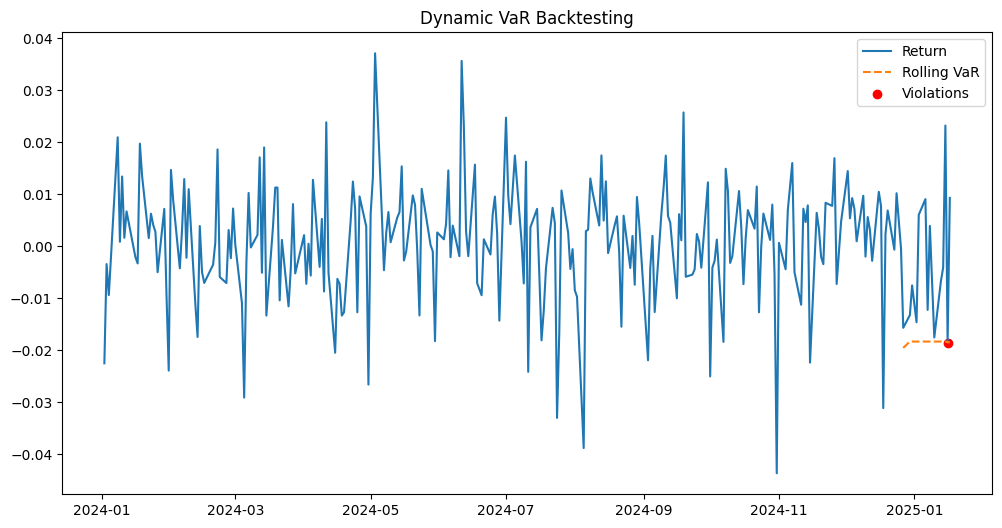

In [22]:
plt.figure(figsize=(12,6))
plt.plot(test["Date"], test["Portfolio_Return"], label="Return")
plt.plot(test["Date"], test["Rolling_VaR"], label="Rolling VaR", linestyle="--")
plt.scatter(test["Date"][test["Breach"]],
            test["Portfolio_Return"][test["Breach"]],
            color="red", label="Violations")

plt.legend()
plt.title("Dynamic VaR Backtesting")
plt.show()


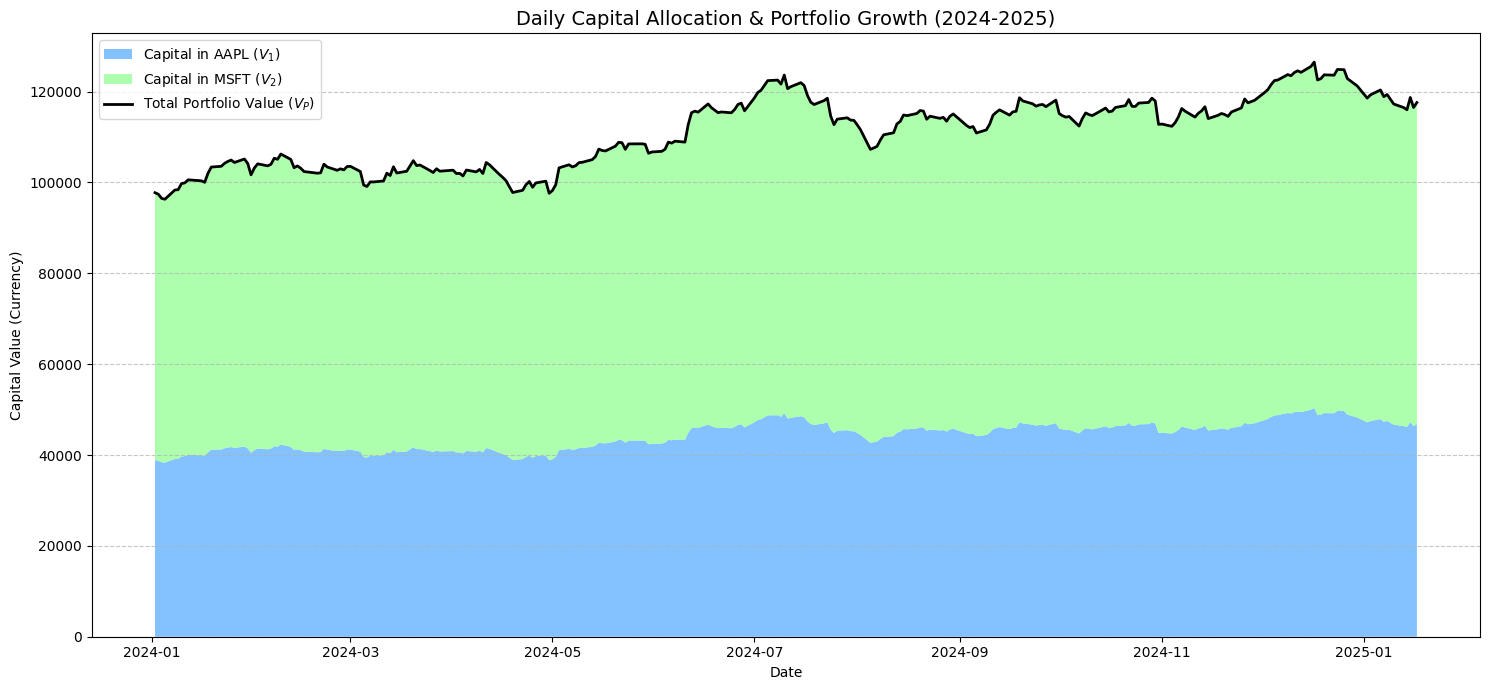

Final Portfolio Value: 117,598.01


In [23]:
import matplotlib.pyplot as plt

# Create the visualization for Capital Allocation (Step 2.iii)
plt.figure(figsize=(15, 7))

# Plotting the stacked area for V_AAPL and V_MSFT using capital_table
plt.stackplot(capital_table["Date"],
              capital_table['V_AAPL'], capital_table['V_MSFT'],
              labels=['Capital in AAPL ($V_1$)', 'Capital in MSFT ($V_2$)'],
              colors=['#66b3ff', '#99ff99'], alpha=0.8)

# Adding the Total Portfolio Value line (V_P)
plt.plot(capital_table["Date"], capital_table['V_P'], color='black', linewidth=2, label='Total Portfolio Value ($V_P$)')

plt.title('Daily Capital Allocation & Portfolio Growth (2024-2025)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Capital Value (Currency)')
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Print a summary of the final state
final_v = capital_table['V_P'].iloc[-1]
print(f"Final Portfolio Value: {final_v:,.2f}")